# html 파싱
저장된 html 파일을 읽어 필요한 정보를 골라내는 작업을 수행

## html 분석

<html lang="ko"><head>
    <meta content="text/html; charset=utf-8" http-equiv="Content-Type">
    <meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0">
    <meta content="kr" name="content-language">
    <meta content="IE=Edge" http-equiv="X-UA-Compatible">
    <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
    <meta http-equiv="content-type" content="text/html; charset=UTF-8">
<meta name="referrer" content="origin-when-crossorigin">
<meta property="fb:app_id" content="347023355469829">
<meta property="og:title" content="오봉집 신대방삼거리역점 - 신대방삼거리역 낙지볶음, 직화낙지볶음 맛집 - 다이닝코드">
<meta property="og:url" content="https://www.diningcode.com/profile.php?rid=72cb96piXhcX">
<meta property="og:site_name" content="다이닝코드">
<meta property="og:description" content="맛5.0, 가격5.0, 친절5.0 생일이라고 동생들이 밥 사줬는데 너무 만족하면서 잘먹었어요 04.10 (금) 영업시간: 11:00 - 22:00  매생이연포탕(32,000원), 오징어오봉집스페셜(58,000원), 얼큰낙지전골(32,000원), 직화오징어볶음(13,00">
<meta property="og:image" content="http
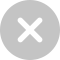
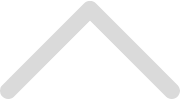

In [87]:
# 샘플 html 로드
with open("restaurants/restaurant_53.txt", "r", encoding="utf-8") as f:
    sample_page = f.read()

print(sample_page)

In [88]:
import re
from bs4 import BeautifulSoup

In [89]:
def textify(tag):
    return "" if tag is None else tag.text.strip()

In [90]:
# BeautifulSoup 객체 생성
page_soup = BeautifulSoup(sample_page, "html.parser")

In [91]:
# 페이지 가장 위쪽 식당 프로필 부분
page_head = page_soup.select_one(".profile-top-wrapper")
print(page_head)

<div class="profile-top-wrapper">
<div class="s-list pic-grade">
<div class="store-pic" style="position:relative; display: flex; justify-content: space-between;"><div class="bimg btn-main-photo-viewer" data-index="0" style="width: 33.3%; height: 220px;"><img alt="오봉집 대표 사진" class="button" src="https://d12zq4w4guyljn.cloudfront.net/300_300_20260226110950_photo1_3c232e2fcc86.webp" style="width:100%; height:100%; object-fit:cover;"/></div><div class="bimg btn-main-photo-viewer" data-index="1" style="width: 33.3%; height: 220px;"><img alt="오봉집 대표 사진" class="button" src="https://d12zq4w4guyljn.cloudfront.net/300_300_20260226110950_photo2_3c232e2fcc86.webp" style="width:100%; height:100%; object-fit:cover;"/></div><div class="bimg btn-main-photo-viewer" data-index="2" style="width: 33.3%; height: 220px;"><img alt="오봉집 대표 사진" class="button" src="https://d12zq4w4guyljn.cloudfront.net/300_300_20260226110950_photo3_3c232e2fcc86.webp" style="width:100%; height:100%; object-fit:cover;"/></div></di

In [92]:
# 각 필드는 빈 이름일 수 있기 때문에 분기가 필요함
page_head = page_soup.select_one(".profile-top-wrapper")

# 식당 이름
restaurant_name = textify(page_head.select_one("h1.tit"))
print(restaurant_name)

# 음식 이미지
imglink = page_head.select_one(".btn-main-photo-viewer").select_one("img").get("src")
print(imglink)

# 지역명과 태그 적힌 필드
desciption_field = page_head.select_one("div.btxt")

# 지역명 (실제로는 다양하지만 이번 예제에서는 신대방삼거리역 뿐)
region = textify(desciption_field.select_one("a.area"))
print(region)

# 식당종류
category = desciption_field.select("a.btxt")
category = [] if category is None else [textify(t) for t in category]
print(category)

# 주소
address = page_head.select("li.locat > a, li.locat > span")
address = [] if address is None else address
address = " ".join([textify(t) for t in address])
print(address)

# 영업시간
work_hour = page_head.select_one("#today-main-hours").text.strip()
work_hour = "" if work_hour is None else work_hour
print(work_hour)
hours = re.findall(r"\d{2}:\d{2}", work_hour)
print(hours)

# 전화번호
tel = textify(page_head.select_one("li.tel"))
print(tel)

# 태그
tags = page_head.select_one("li.tag")
tags = [] if tags is None else tags.select("a")
tags = [textify(t) for t in tags]
print(tags)

# 특징
character = page_head.select_one("li.char")
character = [] if character is None else character.select("a")
character = [textify(t) for t in character]
print(character)

오봉집 신대방삼거리역점
https://d12zq4w4guyljn.cloudfront.net/300_300_20260226110950_photo1_3c232e2fcc86.webp
신대방삼거리역
['낙지볶음', '직화낙지볶음']
서울특별시 동작구 대방동길 6 1층 108호
영업시간: 11:00 - 22:00
['11:00', '22:00']
02-3280-0644
['회식장소', '모임장소']
['불맛', '매콤한', '셀프바', '배달']


In [93]:
# 메뉴 필드
menu_list = page_soup.select_one("#div_detail")
print(menu_list)

<div class="s-list detail-info" id="div_detail" style="">
<!-- s:메뉴정보-->
<div class="menu-info collapsed">
<div class="sticky-header-wrapper" style="position: relative; display: flex; flex-direction: column; width: 100%; box-sizing: border-box; padding-top: 22px; padding-bottom: 12px;"><div class="menu-title-row">
<div class="menu-title-left">
<p class="tit">오봉집 메뉴정보</p>
</div>
<div class="menu-title-right">
<div style="display: flex; align-items: center; gap: 8px;">
<span style="color: #7E7E7E; text-align: center; font-family: 'Noto Sans KR'; font-size: 14px; font-style: normal; font-weight: 500; line-height: 20px; letter-spacing: -0.7px; white-space: nowrap;">인기 메뉴 보기</span>
<button aria-checked="false" class="menu-type-toggle-switch" onclick="toggleSwitch(this)" role="switch" style="position: relative; display: inline-block; width: 38px; height: 22px; border: none; border-radius: 999px; background-color: #d9d9d9; cursor: pointer; padding: 0; box-sizing: border-box; outline: none; tr

In [94]:
# 메뉴 선택
# 마찬가지로 없을 수도 있으니 분기가 필요
menu_list = page_soup.select_one("#div_detail")
menu_list = None if menu_list is None else menu_list.select_one(".list.Restaurant-MenuList")
li_list = [] if menu_list is None else menu_list.select("li")
print(len(li_list))

for li in li_list:
    # 메뉴명
    menu_name = textify(li.select_one("span.restaurant-menu"))

    # 가격
    menu_price = textify(li.select_one("p.restaurant-price"))

    # 설명 (없을 확률 높음)
    menu_desc = textify(li.select_one("p.menu-description"))

    print(f"메뉴명: {menu_name}. 가격: {menu_price}")
    print(f"{menu_desc}")

18
메뉴명: 오징어오봉집스페셜. 가격: 58,000원

메뉴명: 낙지오봉집스페셜. 가격: 59,000원

메뉴명: 보쌈정식. 가격: 12,000원

메뉴명: 바지락칼국수. 가격: 9,000원
2인이상 주문가능
메뉴명: 직화오돌뼈 주먹밥. 가격: 17,000원

메뉴명: 쫀득편육. 가격: 14,000원

메뉴명: 먹태. 가격: 15,000원

메뉴명: 부추전. 가격: 12,000원

메뉴명: 김치전. 가격: 12,000원

메뉴명: 쟁반막국수. 가격: 9,000원

메뉴명: 얼큰낙지전골. 가격: 32,000원

메뉴명: 매생이연포탕. 가격: 32,000원
연포탕+칼국수
메뉴명: 오봉집보쌈(소). 가격: 33,000원

메뉴명: 오봉집보쌈(중). 가격: 38,000원

메뉴명: 오봉집보쌈(대). 가격: 44,000원

메뉴명: 불매운맛 낙지볶음. 가격: 14,000원
2인이상 주문가능
메뉴명: 직화오징어볶음. 가격: 13,000원
2인이상 주문가능
메뉴명: 직화제낙볶음. 가격: 14,000원
2인이상 주문가능


In [95]:
# 리뷰 필드
review_field = page_soup.select_one("div.s-list.appraisal")
print(review_field)

<div class="s-list appraisal">
<p class="tit"><span><span>오봉집 방문자 리뷰</span></span></p>
<!-- s: 평가항목 상세-->
<div class="grade-info" style="min-height:140px;">
<div class="star-point" id="lbl_star_point">
<span class="point">5.0</span>
<div class="star-wrapper">
<span class="star"><i style="width:100%;"></i></span>
</div>
<span class="review-count-sentence"><span class="review-count">1건</span>의 리뷰가
                작성되었어요.</span>
</div>
<ul class="app-graph">
<li class="max-score">
<div class="score-tag">
<span class="score-number">5</span>
</div>
<p class="btxt">최고에요</p>
<p class="graph"><span style="width:100%; background-color: #0088ff;"></span></p>
<p class="score-count">(1)</p>
</li>
<li>
<div class="score-tag">
<span class="score-number">4</span>
</div>
<p class="btxt">만족해요</p>
<p class="graph"><span style="width:0%; background-color: #c4c4c4;"></span></p>
<p class="score-count zero-count">(0)</p>
</li>
<li>
<div class="score-tag">
<span class="score-number">3</span>
</div>
<p class=

In [96]:
reviews = review_field.select("div.latter-graph")
print(len(reviews))

1


In [97]:
# 리뷰 중 하나를 추출
sample_review = reviews[0]
print(sample_review)

<div class="latter-graph" id="div_review_1082842">
<div class="latter-graph-body processed">
<div style="position:absolute; width:54px; height:54px;">
<div style="border-radius:50%; background: url('https://s3-ap-northeast-1.amazonaws.com/dc-user-profile-resized/profilephoto_A_20230910012049_160x160.jpg') no-repeat center; background-size:cover; width:54px;height:54px; margin-top: 14px; box-shadow: inset 0 0 3px rgba(0,0,0,0.08);">
</div>
</div>
<p class="person-grade">
<span class="btxt">
<strong>먼지님</strong>
</span>
<span class="info">
                    평균 별점 <span class="avg_score">4.5</span>  
                    평가 <span class="rv_cnt">532</span>  
                    팔로워 <span class="follower_cnt">47</span>
</span>
</p>
<!--// 사진 -->
<div style="margin:10px 0 16px 0;">
<div style="float:left; display: flex; flex-wrap: wrap; gap: 8px;">
<div class="button btn-gallery-review btn-img-popup" data-date="2월 26일" data-index="0" data-nickname="먼지님" data-origin="https://d12zq4w4guyljn.c

In [98]:
# 리뷰 분석
reviewer_profile = sample_review.select_one("p.person-grade")

# 리뷰어 이름
reviewer_name = textify(reviewer_profile.select_one("span.btxt"))
print(reviewer_name)

# 리뷰어 특징
reviewer_info = reviewer_profile.select_one("span.info")
reviewer_avg_score = textify(reviewer_info.select_one("span.avg_score"))
reviewer_rv_cnt = textify(reviewer_info.select_one("span.rv_cnt"))
reviewer_follower_cnt = textify(reviewer_info.select_one("span.follower_cnt"))
print(reviewer_avg_score, reviewer_rv_cnt, reviewer_follower_cnt)

# 준 점수
reviewer_score = textify(sample_review.select_one(".total_score"))
print(reviewer_score)

# 리뷰 내용
review_content = textify(sample_review.select_one("div.review_contents.btxt"))
print(review_content)

# 분야별 평가
# 순서별로 맛, 가격, 응대
sub_score = sample_review.select_one("div.sub_title_wrapper")
sub_score = [] if sub_score is None else sub_score.select("span.text")
sub_score = [textify(t) for t in sub_score]
print(sub_score)

# 주문 메뉴
reviewer_menu = textify(sample_review.select_one("p.ordered_menu_list"))
reviewer_menu = [t.strip() for t in reviewer_menu.split(',')]
print(reviewer_menu)

# 키워드
reviewer_keywords = textify(sample_review.select_one("p.new-keyword_list"))
reviewer_keywords = [t.strip() for t in reviewer_keywords.split(',')]
print(reviewer_keywords)


먼지님
4.5 532 47
5점
생일이라고 동생들이 밥 사줬는데 너무 만족하면서 잘먹었어요
['좋음', '만족', '좋음']
['매생이연포탕']
['술모임', '푸짐한']


## html to Dataframe

In [99]:
import pandas as pd
from bs4 import BeautifulSoup

In [100]:
def restaurant_info_column() -> tuple:
    """
    dataframe에 사용할 컬럼명 반환
    """
    return ("restaurant_code", "restaurant_name", "img_link", "region",
            "category", "address", "open_time", "close_time",
            "tel_no", "tags", "character")

def parse_restaurant_info(restaurant_code:int, soup:BeautifulSoup) -> tuple:
    """
    input
    restaurant_code(int): 레스토랑 코드
    soup(BeautifulSoup): 분석할 수프 객체

    return
    레스토랑 정보가 담긴 tuple객체
    """
    # 결과값을 담을 필드
    rlist = [restaurant_code,]

    page_head = soup.select_one(".profile-top-wrapper")

    # 식당 이름
    restaurant_name = textify(page_head.select_one("h1.tit"))
    rlist.append(restaurant_name)

    # 음식 이미지
    imglink = page_head.select_one(".btn-main-photo-viewer")
    imglink = None if imglink is None else imglink.select_one("img")
    imglink = "" if imglink is None else imglink.get("src")
    rlist.append(imglink)

    # 지역명과 태그 적힌 필드
    desciption_field = page_head.select_one("div.btxt")

    # 지역명 (실제로는 다양하지만 이번 예제에서는 신대방삼거리역 뿐)
    region = textify(desciption_field.select_one("a.area"))
    rlist.append(region)

    # 식당종류
    category = desciption_field.select("a.btxt")
    category = [] if category is None else [textify(t) for t in category]
    rlist.append(",".join(category))

    # 주소
    address = page_head.select("li.locat > a, li.locat > span")
    address = [] if address is None else address
    address = " ".join([textify(t) for t in address])
    rlist.append(address)

    # 오픈 시간, 폐점 시간
    work_hour = textify(page_head.select_one("#today-main-hours"))
    hours = re.findall(r"\d{2}:\d{2}", work_hour)
    if 2 <= len(hours):
        rlist.append(hours[0])
        rlist.append(hours[1])
    else:
        rlist.append("")
        rlist.append("")

    # 전화번호
    tel = textify(page_head.select_one("li.tel"))
    rlist.append(tel)

    # 태그
    tags = page_head.select_one("li.tag")
    tags = [] if tags is None else tags.select("a")
    tags = [textify(t) for t in tags]
    rlist.append(",".join(tags))

    # 특징
    character = page_head.select_one("li.char")
    character = [] if character is None else character.select("a")
    character = [textify(t) for t in character]
    rlist.append(",".join(character))

    return tuple(rlist)


In [101]:
# parser 테스트
print(restaurant_info_column())
print(parse_restaurant_info(0, page_soup))

('restaurant_code', 'restaurant_name', 'img_link', 'region', 'category', 'address', 'open_time', 'close_time', 'tel_no', 'tags', 'character')
(0, '오봉집 신대방삼거리역점', 'https://d12zq4w4guyljn.cloudfront.net/300_300_20260226110950_photo1_3c232e2fcc86.webp', '신대방삼거리역', '낙지볶음,직화낙지볶음', '서울특별시 동작구 대방동길 6 1층 108호', '11:00', '22:00', '02-3280-0644', '회식장소,모임장소', '불맛,매콤한,셀프바,배달')


In [102]:
def menu_info_column() -> tuple:
    """
    dataframe에 사용될 컬럼명 반환
    """
    return ("restaurant_code", "menu_name", "price", "description")

def parse_menu_info(restaurant_code:int, soup:BeautifulSoup) -> list[tuple]:
    """
    input
    restaurant_code(int): 레스토랑 코드
    soup(BeautifulSoup): 분석할 수프 객체

    return
    레스토랑 메뉴 정보가 담긴 list[tuple]객체
    """
    rlist = []

    menu_list = soup.select_one("#div_detail")
    menu_list = None if menu_list is None else menu_list.select_one(".list.Restaurant-MenuList")
    li_list = [] if menu_list is None else menu_list.select("li")

    for li in li_list:
        # 메뉴명
        menu_name = textify(li.select_one("span.restaurant-menu"))

        # 가격
        menu_price = textify(li.select_one("p.restaurant-price"))

        # 설명 (없을 확률 높음)
        menu_desc = textify(li.select_one("p.menu-description"))

        buff = (restaurant_code, menu_name, menu_price, menu_desc)
        rlist.append(buff)

    return rlist

In [103]:
print(menu_info_column())
menu_list = parse_menu_info(0, page_soup)
for m in menu_list:
    print(m)

('restaurant_code', 'menu_name', 'price', 'description')
(0, '오징어오봉집스페셜', '58,000원', '')
(0, '낙지오봉집스페셜', '59,000원', '')
(0, '보쌈정식', '12,000원', '')
(0, '바지락칼국수', '9,000원', '2인이상 주문가능')
(0, '직화오돌뼈 주먹밥', '17,000원', '')
(0, '쫀득편육', '14,000원', '')
(0, '먹태', '15,000원', '')
(0, '부추전', '12,000원', '')
(0, '김치전', '12,000원', '')
(0, '쟁반막국수', '9,000원', '')
(0, '얼큰낙지전골', '32,000원', '')
(0, '매생이연포탕', '32,000원', '연포탕+칼국수')
(0, '오봉집보쌈(소)', '33,000원', '')
(0, '오봉집보쌈(중)', '38,000원', '')
(0, '오봉집보쌈(대)', '44,000원', '')
(0, '불매운맛 낙지볶음', '14,000원', '2인이상 주문가능')
(0, '직화오징어볶음', '13,000원', '2인이상 주문가능')
(0, '직화제낙볶음', '14,000원', '2인이상 주문가능')


In [104]:
def reviews_column() -> tuple:
    """
    dataframe에 사용될 컬럼명 반환
    """
    return ("restaurant_code", "reviewer_name",
            "reviewer_avg_score", "reviewer_rv_cnt", "reviewer_follower_cnt",
            "reviewer_score", "taste_level", "price_level", "service_level",
            "review_content", "review_menu", "keywords"
            )

def parse_reviews(restaurant_code:int, soup:BeautifulSoup) -> list[tuple]:
    """
    input
    restaurant_code(int): 레스토랑 코드
    soup(BeautifulSoup): 분석할 수프 객체

    return
    레스토랑 리뷰 정보가 담긴 list[tuple]객체
    """
    rlist = []

    review_field = soup.select_one("div.s-list.appraisal")
    reviews = [] if review_field is None else review_field.select("div.latter-graph")

    for r in reviews:
        buff = [restaurant_code]

        # 리뷰 분석
        reviewer_profile = r.select_one("p.person-grade")

        # 리뷰어 이름
        reviewer_name = textify(reviewer_profile.select_one("span.btxt"))
        buff.append(reviewer_name)

        # 리뷰어 특징
        reviewer_info = reviewer_profile.select_one("span.info")
        reviewer_avg_score = textify(reviewer_info.select_one("span.avg_score"))
        buff.append(reviewer_avg_score)
        reviewer_rv_cnt = textify(reviewer_info.select_one("span.rv_cnt"))
        buff.append(reviewer_rv_cnt)
        reviewer_follower_cnt = textify(reviewer_info.select_one("span.follower_cnt"))
        buff.append(reviewer_follower_cnt)
        
        # 준 점수
        reviewer_score = textify(r.select_one(".total_score"))
        buff.append(reviewer_score)

        # 분야별 평가
        # 순서별로 맛, 가격, 응대
        sub_score = r.select_one("div.sub_title_wrapper")
        sub_score = [] if sub_score is None else sub_score.select("span.text")
        sub_score = [textify(t) for t in sub_score]
        for i in range(3):
            sc = "" if len(sub_score) <= i else sub_score[i]
            buff.append(sc)
        
        # 리뷰 내용
        review_content = textify(r.select_one("div.review_contents.btxt"))
        buff.append(review_content)
        
        # 리뷰어 주문한 메뉴 목록
        reviewer_menu = textify(r.select_one("p.ordered_menu_list"))
        reviewer_menu = [t.strip() for t in reviewer_menu.split(',')]
        buff.append(",".join(reviewer_menu))

        # 키워드
        reviewer_keywords = textify(r.select_one("p.new-keyword_list"))
        reviewer_keywords = [t.strip() for t in reviewer_keywords.split(',')]
        buff.append(",".join(reviewer_keywords))
        
        rlist.append(tuple(buff))
        
    return rlist


In [105]:
print(reviews_column())
reviews = parse_reviews(0, page_soup)
for r in reviews:
    print(r)

('restaurant_code', 'reviewer_name', 'reviewer_avg_score', 'reviewer_rv_cnt', 'reviewer_follower_cnt', 'reviewer_score', 'taste_level', 'price_level', 'service_level', 'review_content', 'review_menu', 'keywords')
(0, '먼지님', '4.5', '532', '47', '5점', '좋음', '만족', '좋음', '생일이라고 동생들이 밥 사줬는데 너무 만족하면서 잘먹었어요', '매생이연포탕', '술모임,푸짐한')


In [106]:
restaurant_list = []
menu_list = []
review_list = []

# for loop를 활용해서 모든 html을 순회
for i in range(100):
    print(f"{i+1}번째 restaurant 분석 중...")
    with open(f"restaurants/restaurant_{i}.txt", "r", encoding="utf-8") as f:
        html = f.read()

    soup = BeautifulSoup(html, "html.parser")
    
    restaurant_list.append(parse_restaurant_info(i, soup))

    sub_menu = parse_menu_info(i, soup)
    for m in sub_menu:
        menu_list.append(m)

    sub_reviews = parse_reviews(i, soup)
    for r in sub_reviews:
        review_list.append(r)

restaurant_df = pd.DataFrame(restaurant_list, columns=restaurant_info_column())
menu_df = pd.DataFrame(menu_list, columns=menu_info_column())
review_df = pd.DataFrame(review_list, columns=reviews_column())

1번째 restaurant 분석 중...
2번째 restaurant 분석 중...
3번째 restaurant 분석 중...
4번째 restaurant 분석 중...
5번째 restaurant 분석 중...
6번째 restaurant 분석 중...
7번째 restaurant 분석 중...
8번째 restaurant 분석 중...
9번째 restaurant 분석 중...
10번째 restaurant 분석 중...
11번째 restaurant 분석 중...
12번째 restaurant 분석 중...
13번째 restaurant 분석 중...
14번째 restaurant 분석 중...
15번째 restaurant 분석 중...
16번째 restaurant 분석 중...
17번째 restaurant 분석 중...
18번째 restaurant 분석 중...
19번째 restaurant 분석 중...
20번째 restaurant 분석 중...
21번째 restaurant 분석 중...
22번째 restaurant 분석 중...
23번째 restaurant 분석 중...
24번째 restaurant 분석 중...
25번째 restaurant 분석 중...
26번째 restaurant 분석 중...
27번째 restaurant 분석 중...
28번째 restaurant 분석 중...
29번째 restaurant 분석 중...
30번째 restaurant 분석 중...
31번째 restaurant 분석 중...
32번째 restaurant 분석 중...
33번째 restaurant 분석 중...
34번째 restaurant 분석 중...
35번째 restaurant 분석 중...
36번째 restaurant 분석 중...
37번째 restaurant 분석 중...
38번째 restaurant 분석 중...
39번째 restaurant 분석 중...
40번째 restaurant 분석 중...
41번째 restaurant 분석 중...
42번째 restaurant 분석 중...
4

In [107]:
restaurant_df.head()

,restaurant_code,restaurant_name,img_link,region,category,address,open_time,close_time,tel_no,tags,character
0,0,유태우스시,https://d12zq4w4guyljn.cloudfront.net/300_300_...,신대방삼거리역,"스시,회전초밥",서울특별시 동작구 보라매로 113 1층 유태우스시,11:00,22:00,0507-1358-1246,"데이트,혼밥","가성비좋은,서민적인,점심식사,저녁식사,바테이블,다찌석"
1,1,듀윗,https://d12zq4w4guyljn.cloudfront.net/300_300_...,신대방삼거리역,"디저트,케이크",서울특별시 동작구 대방동1길 10 1층,08:00,21:00,0507-2093-6672,"데이트,기념일","예쁜,깔끔한,점심식사,테이크아웃,예약가능"
2,2,한제소곱창전골 신대방삼거리역점,https://d12zq4w4guyljn.cloudfront.net/300_300_...,신대방삼거리역,"곱창전골,소곱창전골","서울특별시 동작구 여의대방로22길 121 상가동 1층 1444호, 1445호",16:00,00:00,0507-1359-9161,"술모임,해장용","지역주민이찾는,매콤한,저녁식사,예약가능,배달"
3,3,프로스퍼,https://d12zq4w4guyljn.cloudfront.net/300_300_...,신대방삼거리역,"카페,커피",서울특별시 동작구 여의대방로24길 101 1층,10:00,00:00,0507-1361-3276,"차모임,혼자카페","캐주얼한,카공,점심식사,테이크아웃,와이파이"
4,4,일진아구찜,https://d12zq4w4guyljn.cloudfront.net/300_300_...,신대방삼거리역,아구찜,서울특별시 동작구 여의대방로24길 93 1층,11:00,22:00,02-817-5554,가족외식,"서민적인,매콤한,점심식사,저녁식사,유아의자"


In [108]:
menu_df.head()

,restaurant_code,menu_name,price,description
0,0,회전초밥,,
1,0,장어초밥,,
2,1,프레지에 1호 홀케이크,"50,000원",
3,1,프레지에,"10,500원",
4,1,페르디셔 압펠,"6,000원",


In [109]:
review_df.head()

,restaurant_code,reviewer_name,reviewer_avg_score,reviewer_rv_cnt,reviewer_follower_cnt,reviewer_score,taste_level,price_level,service_level,review_content,review_menu,keywords
0,0,냐밍,4.3,355,69,4점,좋음,만족,보통,요즘 회전초밥집 정말 비싼데 여긴 가성비 갑이었어요! 위치는 조금 복잡한 곳에 있긴...,회전초밥,"저녁식사,식사모임,캐주얼한,이국적/이색적,가성비좋은"
1,0,발통이,4.5,113,1,4점,보통,만족,좋음,한접시에 1500원이면 저렴해요 근데 맛도 생각보다 괜찮았어요! 엄청난 퀄리티는 아...,스시,"점심식사,지역주민이찾는"
2,0,우리의나날,4.5,420,2,5점,좋음,만족,좋음,생일날 갔어요. 저녁시간 웨이팅있었지만 금방 자리에 앉았어요. 회전초밥 모든접시가 ...,회전초밥 1500원,"저녁식사,데이트,서민적인,푸짐한,지역주민이찾는"
3,0,냠냠냠히,4.8,71,0,5점,좋음,만족,좋음,"모든접시 1,700원 이라는 가성비에 맛도 좋고 이런 굿굿!!","연어,장어","저녁식사,가성비좋은"
4,0,밍민,4.8,232,2,5점,좋음,만족,좋음,1500원이라가성비좋아요 다양하게 먹을 수 있고 여러가지종류있어서 좋아요,회전초밥,"점심식사,캐주얼한"


In [110]:
restaurant_df.to_csv("db_csv/restaurant_df.csv", index=False)
menu_df.to_csv("db_csv/menu_df.csv", index=False)
review_df.to_csv("db_csv/review_df.csv", index=False)